# Rodda Gait Pattern Classification
## Joint-wise Multi-Model Comparison: KNN · SVM · Random Forest · Logistic Regression

**Dataset:** Sagittal-plane joint angles (hip, knee, ankle) — children with cerebral palsy  
**Classes:** True, Apparent, Crouch, Jump  
**Goal:** Compare classification performance across 7 joint configurations and 4 classifiers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, train_test_split,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix
)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1 · Load Data and Preprocessing

In [4]:
# Load the dataset (upload file first)
data = pd.read_csv("cp_data_new.csv")

# Eliminate the first row and column (index artifacts from export)
data = data.iloc[1:, 1:]

# Separate features (X) and target labels (y)
X = data.iloc[:, :-1].values.astype(float)
y = data.iloc[:, -1].values

y = pd.Series(y).astype(str).str.strip().str.lower().to_numpy()

# Eliminate outliers using Z-score threshold of 3.5
z_scores = np.abs((X - X.mean(axis=0)) / X.std(axis=0))
threshold = 3.5
mask = (z_scores < threshold).all(axis=1)
X = X[mask]
y = y[mask]

# Encode class labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# Feature layout: 300 columns = 100 hip | 100 knee | 100 ankle
n_samples, n_features = X.shape   # n_features should be 300
n_per_joint = n_features // 3     # 100

# Reshape to (n_samples, 3, 100) for visualisation only
X_multi_dim = X.reshape(n_samples, 3, n_per_joint)

print("Original class distribution:")
unique, counts = np.unique(y_encoded, return_counts=True)
print(np.asarray((unique, counts)).T)
print("-" * 40)
print(f"Total samples      : {n_samples}")
print(f"Features per joint : {n_per_joint}")
print(f"Classes            : {class_names}")

Original class distribution:
[[  0 152]
 [  1 186]
 [  2 201]
 [  3 294]]
----------------------------------------
Total samples      : 833
Features per joint : 100
Classes            : ['apparent' 'crouch' 'jump' 'true']


## Data Visualisation

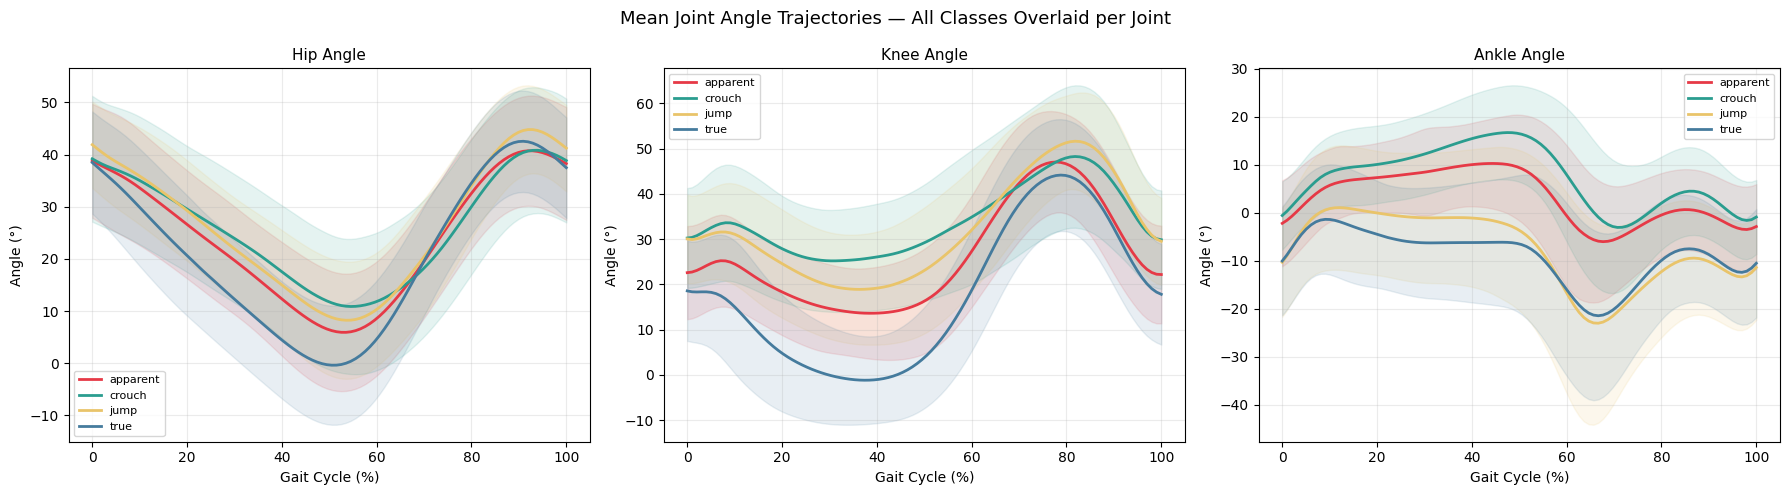

Saved: mean_trajectories_by_joint.png


In [28]:
# Mean Joint Angle Trajectories per Rodda Class 
# For each class, compute the average angle at every gait-cycle time point

gait_pct = np.linspace(0, 100, n_per_joint)   # x-axis: gait cycle percentage
class_colors = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D']  # one colour per class

joint_labels = ["Hip", "Knee", "Ankle"]

# one subplot per joint, all classes overlaid
fig1, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Mean Joint Angle Trajectories — All Classes Overlaid per Joint",
              fontsize=13)

for j, (jname, ax) in enumerate(zip(joint_labels, axes2)):
    for i, class_label in enumerate(np.unique(y_encoded)):
        class_mask = (y_encoded == class_label)
        joint_data = X_multi_dim[class_mask, j, :]   # (n_class, 100)
        mean_traj  = joint_data.mean(axis=0)
        std_traj   = joint_data.std(axis=0)
        c = class_colors[i]
        ax.plot(gait_pct, mean_traj, color=c, linewidth=2,
                label=class_names[class_label])
        ax.fill_between(gait_pct,
                        mean_traj - std_traj,
                        mean_traj + std_traj,
                        color=c, alpha=0.12)
    ax.set_title(f"{jname} Angle", fontsize=11)
    ax.set_xlabel("Gait Cycle (%)")
    ax.set_ylabel("Angle (°)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("mean_trajectories_by_joint.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mean_trajectories_by_joint.png")

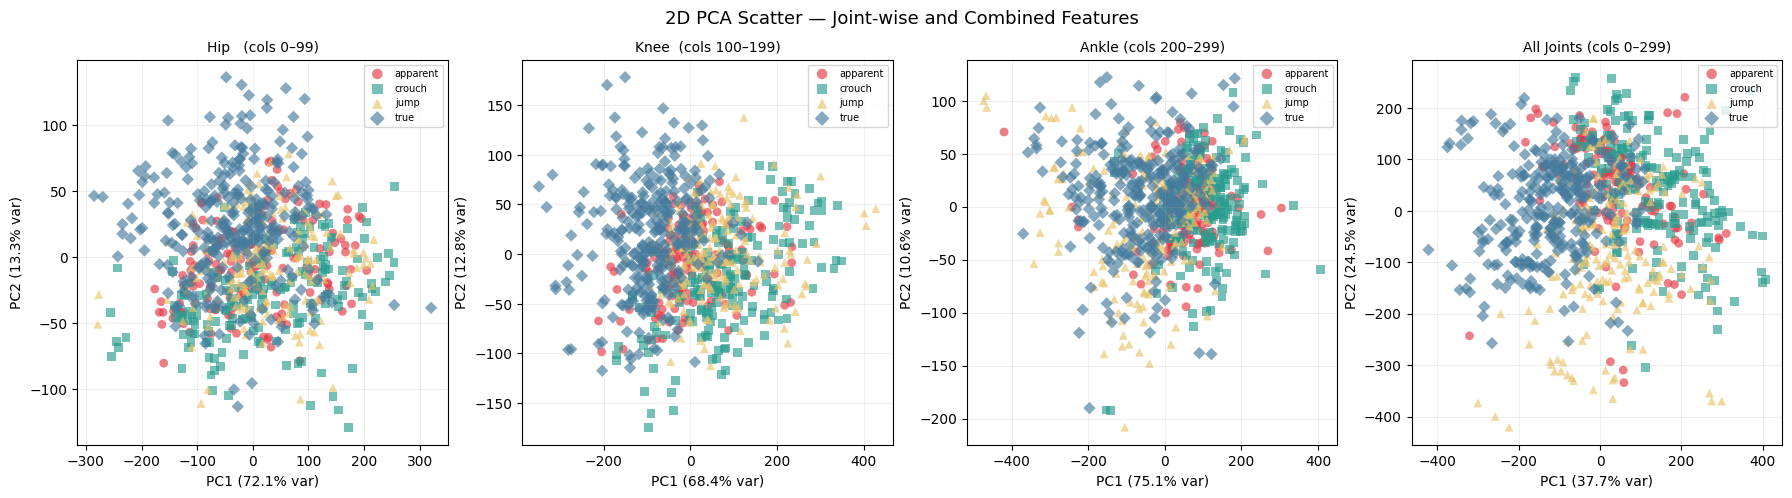


Explained variance (PC1 + PC2) per PCA configuration:
-------------------------------------------------------
  Hip                   : PC1=72.1%  PC2=13.3%  Total=85.4%
  Knee                  : PC1=68.4%  PC2=12.8%  Total=81.1%
  Ankle                 : PC1=75.1%  PC2=10.6%  Total=85.7%
  All Joints            : PC1=37.7%  PC2=24.5%  Total=62.2%


In [32]:
# Joint-wise PCA (2D) + Combined PCA 
# PCA is run separately on each joint's 100 features and on all 300 together.

pca_configs = {
    "Hip   (cols 0–99)":      list(range(0,   100)),
    "Knee  (cols 100–199)":   list(range(100, 200)),
    "Ankle (cols 200–299)":   list(range(200, 300)),
    "All Joints (cols 0–299)":list(range(0,   300)),
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("2D PCA Scatter — Joint-wise and Combined Features",
             fontsize=13)

markers = ['o', 's', '^', 'D']

for ax, (title, col_idx) in zip(axes, pca_configs.items()):
    X_sub = X[:, col_idx]

    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca2 = pca2.fit_transform(X_sub)

    var1 = pca2.explained_variance_ratio_[0] * 100
    var2 = pca2.explained_variance_ratio_[1] * 100

    for i, class_label in enumerate(np.unique(y_encoded)):
        mask = (y_encoded == class_label)
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                   c=class_colors[i], marker=markers[i],
                   label=class_names[class_label],
                   alpha=0.65, s=40, edgecolors='none')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f"PC1 ({var1:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var2:.1f}% var)")
    ax.legend(fontsize=7, loc='best', markerscale=1.2)
    ax.grid(True, alpha=0.2)
plt.show()

# Print explained variance summary
print("\nExplained variance (PC1 + PC2) per PCA configuration:")
print("-" * 55)
for title, col_idx in pca_configs.items():
    X_sub = X[:, col_idx]
    pca_tmp = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_sub)
    total_var = pca_tmp.explained_variance_ratio_.sum() * 100
    print(f"  {title.split('(')[0].strip():<22}: "
          f"PC1={pca_tmp.explained_variance_ratio_[0]*100:.1f}%  "
          f"PC2={pca_tmp.explained_variance_ratio_[1]*100:.1f}%  "
          f"Total={total_var:.1f}%")

# 2 · Joint Configurations

In [7]:
# Define joint configurations as column index slices
# Each entry: (label, column indices)
joint_configs = {
    "Hip":             list(range(0,   100)),
    "Knee":            list(range(100, 200)),
    "Ankle":           list(range(200, 300)),
    "Hip+Knee":        list(range(0,   200)),
    "Hip+Ankle":       list(range(0,   100)) + list(range(200, 300)),
    "Knee+Ankle":      list(range(100, 300)),
    "All Joints":      list(range(0,   300)),
}

config_names = list(joint_configs.keys())
print("Joint configurations defined:")
for name, cols in joint_configs.items():
    print(f"  {name:15s}: {len(cols)} features")

Joint configurations defined:
  Hip            : 100 features
  Knee           : 100 features
  Ankle          : 100 features
  Hip+Knee       : 200 features
  Hip+Ankle      : 200 features
  Knee+Ankle     : 200 features
  All Joints     : 300 features


# 3 · Train / Test Split and Preprocessing Strategy


In [8]:
# Single global 80/20 stratified split — reused for ALL configs and ALL models
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"Training samples : {X_train_raw.shape[0]}")
print(f"Test samples     : {X_test_raw.shape[0]}")
print("\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
print(np.asarray((unique, counts)).T)
print("\nClass distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
print(np.asarray((unique, counts)).T)

Training samples : 666
Test samples     : 167

Class distribution in training set:
[[  0 121]
 [  1 149]
 [  2 161]
 [  3 235]]

Class distribution in test set:
[[ 0 31]
 [ 1 37]
 [ 2 40]
 [ 3 59]]


# 4 · Classifier Definitions and Hyperparameter Grids


In [37]:
# KNN
# Scaler already applied upstream (before SMOTE), so KNN receives scaled data.
# K is selected via manual 10-fold CV to keep the same structure as before.
K_RANGE = list(range(1, 16, 2))   # [1, 3, 5, 7, 9, 11, 13, 15]

def get_best_knn(X_tr, y_tr):
    """Select best K via 10-fold stratified CV; return fitted model + best K + CV scores."""
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    k_cv_scores = {}
    for k in K_RANGE:
        scores = cross_val_score(
            KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform'),
            X_tr, y_tr, cv=skf, scoring='accuracy'
        )
        k_cv_scores[k] = scores

    best_k   = max(k_cv_scores, key=lambda k: k_cv_scores[k].mean())
    best_scores = k_cv_scores[best_k]

    knn_final = KNeighborsClassifier(
        n_neighbors=best_k, metric='euclidean', weights='uniform'
    )
    knn_final.fit(X_tr, y_tr)
    return knn_final, best_k, best_scores

# ______________________________________________________________
# SVM
# Pipeline: StandardScaler -> SVC
# GridSearchCV with 5-fold stratified CV.
# X_tr passed here is RAW (not yet scaled) so the Pipeline can scale per fold.

def get_best_svm(X_tr_raw, y_tr):
    # GridSearchCV over C, kernel, gamma; return best fitted model + CV result summary.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(random_state=RANDOM_STATE, probability=False))
    ])

    param_grid = {
        'svm__C':      [0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma':  ['scale', 0.01, 0.1],   # gamma ignored for linear kernel
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(
        pipe, param_grid, cv=cv,
        scoring='accuracy', n_jobs=-1, refit=True, verbose=0
    )
    gs.fit(X_tr_raw, y_tr)

    best_params  = gs.best_params_
    best_score   = gs.best_score_
    # Extract fold scores for the best parameter combination
    best_idx     = gs.best_index_
    fold_scores  = np.array([
        gs.cv_results_[f'split{i}_test_score'][best_idx] for i in range(5)
    ])
    return gs.best_estimator_, best_params, fold_scores

# ______________________________________________________________
# Random Forest
# Pipeline: StandardScaler -> RandomForestClassifier (RF does not need scaling,
# but keeping it in the Pipeline ensures consistency and correct CV behaviour).
# RandomizedSearchCV with 5-fold CV and 40 random draws.

def get_best_rf(X_tr_raw, y_tr):
    """RandomizedSearchCV over RF hyperparameters; return best model + CV summary."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('rf',     RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])

    param_dist = {
        'rf__n_estimators':      [100, 200, 300, 500, 700, 1000],
        'rf__max_depth':         [None, 5, 10, 20, 30],
        'rf__min_samples_split': [2, 5, 10],
        'rf__min_samples_leaf':  [1, 2, 4],
        'rf__max_features':      ['sqrt', 'log2', 0.3, 0.5],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rs = RandomizedSearchCV(
        pipe, param_dist,
        n_iter=40, cv=cv,
        scoring='accuracy', n_jobs=-1, refit=True,
        random_state=RANDOM_STATE, verbose=0
    )
    rs.fit(X_tr_raw, y_tr)

    best_params = rs.best_params_
    best_idx    = rs.best_index_
    fold_scores = np.array([
        rs.cv_results_[f'split{i}_test_score'][best_idx] for i in range(5)
    ])
    return rs.best_estimator_, best_params, fold_scores

# ______________________________________________________________
# Logistic Regression
# Pipeline: StandardScaler -> LogisticRegression
# GridSearchCV with 5-fold CV.

def get_best_lr(X_tr_raw, y_tr):
    """GridSearchCV over C and solver; return best model + CV summary."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(max_iter=2000,
                                      random_state=RANDOM_STATE))
    ])

    param_grid = {
        'lr__C':      [0.01, 0.1, 1, 10, 100],
        'lr__solver': ['lbfgs', 'saga'],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(
        pipe, param_grid, cv=cv,
        scoring='accuracy', n_jobs=-1, refit=True, verbose=0
    )
    gs.fit(X_tr_raw, y_tr)

    best_params = gs.best_params_
    best_idx    = gs.best_index_
    fold_scores = np.array([
        gs.cv_results_[f'split{i}_test_score'][best_idx] for i in range(5)
    ])
    return gs.best_estimator_, best_params, fold_scores


MODEL_NAMES = ["KNN", "SVM", "Random Forest", "Logistic Regression"]
print("Classifiers defined:")
print("  KNN                 — manual 10-fold CV, K in [1,3,5,7,9,11,13,15]")
print("  SVM                 — GridSearchCV 5-fold, 18 param combos")
print("  Random Forest       — RandomizedSearchCV 5-fold, 40 random draws")
print("  Logistic Regression — GridSearchCV 5-fold, 10 param combos")


Classifiers defined:
  KNN                 — manual 10-fold CV, K in [1,3,5,7,9,11,13,15]
  SVM                 — GridSearchCV 5-fold, 18 param combos
  Random Forest       — RandomizedSearchCV 5-fold, 40 random draws
  Logistic Regression — GridSearchCV 5-fold, 10 param combos


# 5 · Main Experiment — All Configs × All Models


In [ ]:
# Storage for results
results         = []        
all_y_pred      = {}        # y_pred on test set
knn_best_k      = {}        
best_params_log = {}        
cv_scores_log   = {}        # array of 5 or 10 fold scores

print("Running experiments...\n")
print(f"{'Config':<15} {'Model':<20} {'CV Mean':>8} {'CV Std':>7} "
      f"{'TestAcc':>8} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("-" * 78)

for config_name, col_idx in joint_configs.items():

    # 1. Extract feature subset
    X_tr_raw = X_train_raw[:, col_idx]   
    X_te_raw = X_test_raw[:,  col_idx]   

    # 2. SMOTE on raw training data
    # Applied before any scaling so that SMOTE sees the original feature space.
    # Pipeline models will scale internally per CV fold; KNN scales after SMOTE.
    smote = SMOTE(random_state=RANDOM_STATE)
    X_tr_res_raw, y_tr_res = smote.fit_resample(X_tr_raw, y_train)

    # Pre-scale SMOTE data for KNN (KNN does not use Pipeline)
    scaler_knn = StandardScaler()
    X_tr_res_knn = scaler_knn.fit_transform(X_tr_res_raw)
    X_te_knn     = scaler_knn.transform(X_te_raw)

    for model_name in MODEL_NAMES:

        # 3. Train with hyperparameter search
        if model_name == "KNN":
            clf, best_k, fold_scores = get_best_knn(X_tr_res_knn, y_tr_res)
            knn_best_k[config_name] = best_k
            best_params_log[(config_name, model_name)] = {"n_neighbors": best_k}
            y_pred = clf.predict(X_te_knn)

        elif model_name == "SVM":
            clf, bp, fold_scores = get_best_svm(X_tr_res_raw, y_tr_res)
            best_params_log[(config_name, model_name)] = bp
            y_pred = clf.predict(X_te_raw)   # Pipeline scales internally

        elif model_name == "Random Forest":
            clf, bp, fold_scores = get_best_rf(X_tr_res_raw, y_tr_res)
            best_params_log[(config_name, model_name)] = bp
            y_pred = clf.predict(X_te_raw)

        else:   # Logistic Regression
            clf, bp, fold_scores = get_best_lr(X_tr_res_raw, y_tr_res)
            best_params_log[(config_name, model_name)] = bp
            y_pred = clf.predict(X_te_raw)

        # 5. Metrics
        all_y_pred[(config_name, model_name)] = y_pred
        cv_scores_log[(config_name, model_name)] = fold_scores

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='macro',    zero_division=0)
        f1   = f1_score(y_test, y_pred, average='macro',        zero_division=0)

        results.append({
            "Config":    config_name,
            "Model":     model_name,
            "CV Mean":   round(fold_scores.mean(), 4),
            "CV Std":    round(fold_scores.std(),  4),
            "Accuracy":  round(acc,  4),
            "Precision": round(prec, 4),
            "Recall":    round(rec,  4),
            "F1":        round(f1,   4),
        })

        suffix = f"(K={best_k})" if model_name == "KNN" else ""
        print(f"{config_name:<15} {(model_name+suffix):<20} "
              f"{fold_scores.mean():8.4f} {fold_scores.std():7.4f} "
              f"{acc:8.4f} {prec:6.4f} {rec:6.4f} {f1:6.4f}")

    print()

results_df = pd.DataFrame(results)
print(f"\nDone. Total experiments: {len(results)}")


Running experiments (this will take several minutes due to grid search)...

Config          Model                 CV Mean  CV Std  TestAcc   Prec    Rec     F1
------------------------------------------------------------------------------
Hip             KNN(K=1)               0.7511  0.0191   0.5329 0.5243 0.5197 0.5188
Hip             SVM                    0.7553  0.0207   0.5329 0.5148 0.5048 0.5073
Hip             Random Forest          0.6926  0.0261   0.5509 0.5265 0.5216 0.5200
Hip             Logistic Regression    0.5340  0.0198   0.4551 0.4292 0.4329 0.4290

Knee            KNN(K=1)               0.8309  0.0455   0.6647 0.6428 0.6429 0.6412
Knee            SVM                    0.8298  0.0291   0.6587 0.6316 0.6207 0.6237
Knee            Random Forest          0.7926  0.0247   0.5749 0.5434 0.5299 0.5322
Knee            Logistic Regression    0.5926  0.0119   0.5509 0.5189 0.5254 0.5169

Ankle           KNN(K=1)               0.8309  0.0370   0.6527 0.6425 0.6404 0.6377
Ank

# 6 · Results Summary Tables


In [ ]:
def highlight_row_max(row):
    is_max = row == row.max()
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_max]

# Test Accuracy
pivot_acc = results_df.pivot(index="Config", columns="Model", values="Accuracy").reindex(config_names)
display(
    pivot_acc.style
    .apply(highlight_row_max, axis=1)
    .format("{:.4f}")
    .set_caption("Test Accuracy")
)

# F1-Score
pivot_f1 = results_df.pivot(index="Config", columns="Model", values="F1").reindex(config_names)
display(
    pivot_f1.style
    .apply(highlight_row_max, axis=1)
    .format("{:.4f}")
    .set_caption("F1-Score ")
)


Model,KNN,Logistic Regression,Random Forest,SVM
Config,,,,
Hip,0.5329,0.4551,0.5509,0.5329
Knee,0.6647,0.5509,0.5749,0.6587
Ankle,0.6527,0.5329,0.5808,0.6228
Hip+Knee,0.7665,0.5449,0.6467,0.7365
Hip+Ankle,0.7904,0.5689,0.7186,0.7246
Knee+Ankle,0.8144,0.6766,0.7545,0.7844
All Joints,0.8263,0.6527,0.7425,0.8204


Model,KNN,Logistic Regression,Random Forest,SVM
Config,,,,
Hip,0.5188,0.4290,0.5200,0.5073
Knee,0.6412,0.5169,0.5322,0.6237
Ankle,0.6377,0.5113,0.5619,0.5940
Hip+Knee,0.7502,0.5188,0.6104,0.7206
Hip+Ankle,0.7794,0.5453,0.6910,0.7009
Knee+Ankle,0.8030,0.6598,0.7278,0.7671
All Joints,0.8122,0.6347,0.7110,0.8081


# 7 · Line Chart — All Models per Joint Configuration

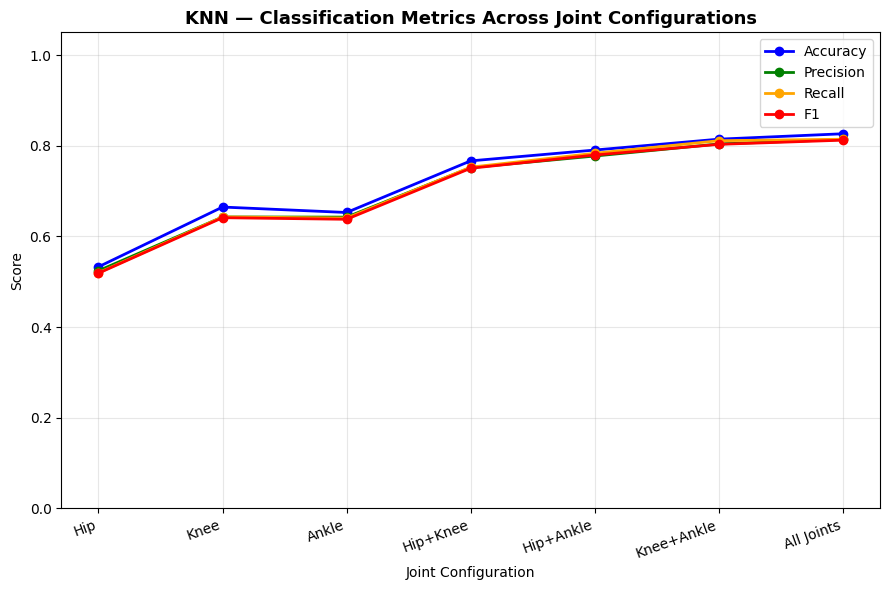

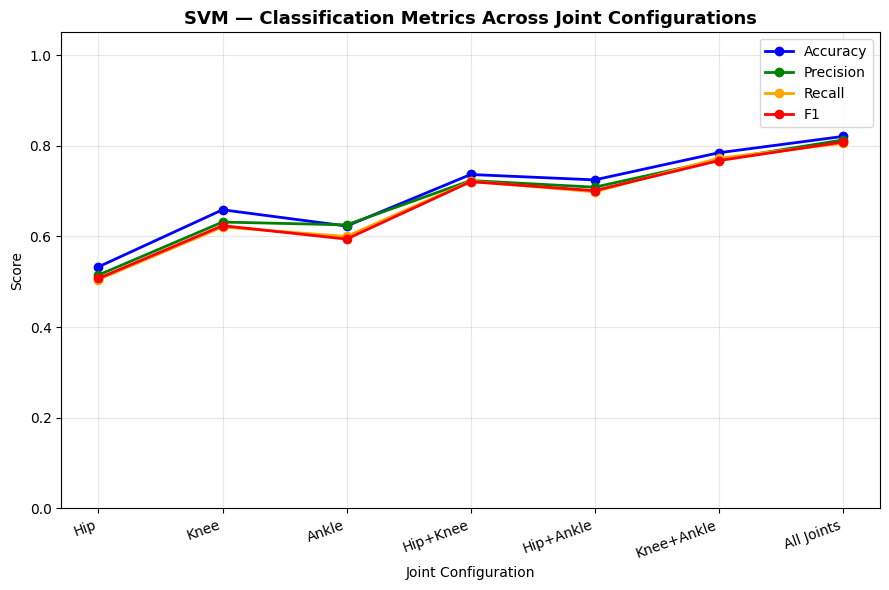

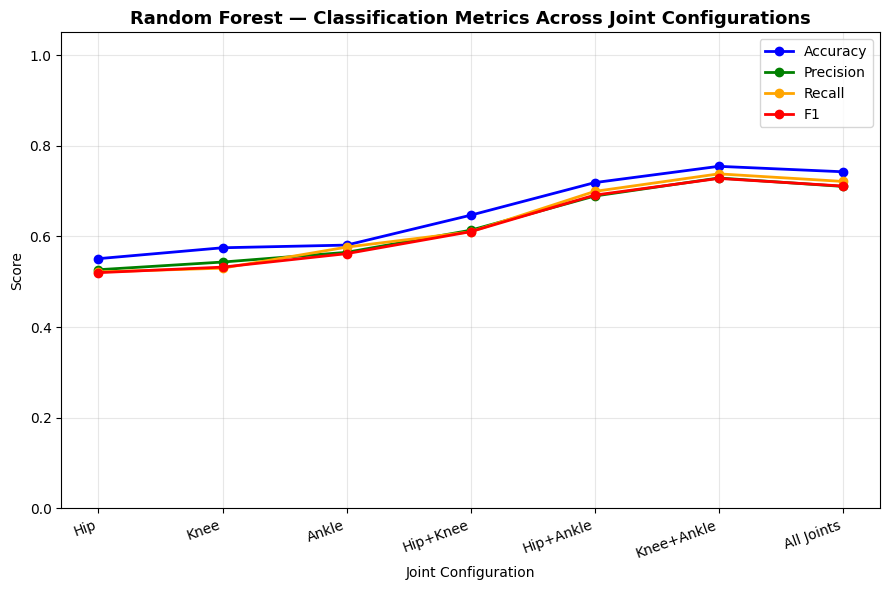

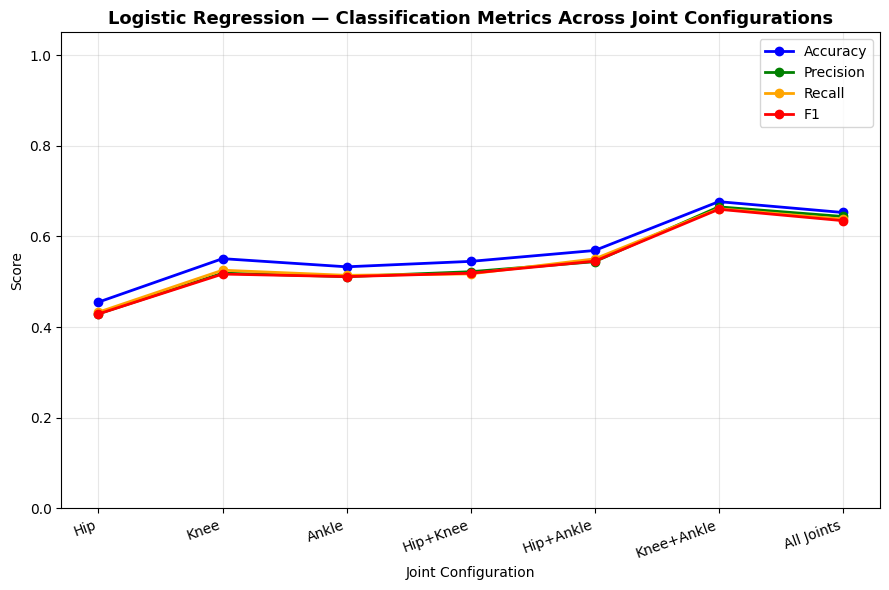

In [39]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
metric_colors = ['blue', 'green', 'orange', 'red']

for model in MODEL_NAMES:
    plt.figure(figsize=(9, 6))  # هر بار یک figure جدید
    
    subset = results_df[results_df["Model"] == model] \
                .set_index("Config") \
                .reindex(config_names)
    
    x = range(len(config_names))
    
    for metric, color in zip(metrics, metric_colors):
        plt.plot(x, subset[metric],
                 marker='o',
                 label=metric,
                 color=color,
                 linewidth=2)
    
    plt.title(f"{model} — Classification Metrics Across Joint Configurations",
              fontsize=13,
              fontweight='bold')
    
    plt.xticks(list(x), config_names, rotation=20, ha='right')
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.xlabel("Joint Configuration")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# 8 · Detailed Classification Reports

Per-class precision, recall, and F1-score for every combination of joint configuration and classifier.

In [20]:
for config_name in config_names:
    print(f"\n{'='*70}")
    print(f"  JOINT CONFIGURATION: {config_name}")
    print(f"{'='*70}")
    for model_name in MODEL_NAMES:
        y_pred = all_y_pred[(config_name, model_name)]
        suffix = f"  [best K={knn_best_k[config_name]}]" if model_name == "KNN" else ""
        print(f"\n  ── {model_name}{suffix} ──")
        print(classification_report(y_test, y_pred, target_names=class_names, digits=4))
    print()


  JOINT CONFIGURATION: Hip

  ── KNN  [best K=1] ──
              precision    recall  f1-score   support

    apparent     0.5000    0.3871    0.4364        31
      crouch     0.5000    0.5405    0.5195        37
        jump     0.4792    0.5750    0.5227        40
        true     0.6182    0.5763    0.5965        59

    accuracy                         0.5329       167
   macro avg     0.5243    0.5197    0.5188       167
weighted avg     0.5368    0.5329    0.5320       167


  ── SVM ──
              precision    recall  f1-score   support

    apparent     0.4583    0.3548    0.4000        31
      crouch     0.4865    0.4865    0.4865        37
        jump     0.5263    0.5000    0.5128        40
        true     0.5882    0.6780    0.6299        59

    accuracy                         0.5329       167
   macro avg     0.5148    0.5048    0.5073       167
weighted avg     0.5267    0.5329    0.5274       167


  ── Random Forest ──
              precision    recall  f1-sco

# 9 · Confusion Matrices — Best configurations

Selected cases for confusion matrix visualisation:
  Group                Config          Model                  F1
  --------------------------------------------------------------------
  Best Single-Joint    Knee            KNN                    0.6412
  Best Two-Joint       Knee+Ankle      KNN                    0.8030
  Best Three-Joint     All Joints      KNN                    0.8122


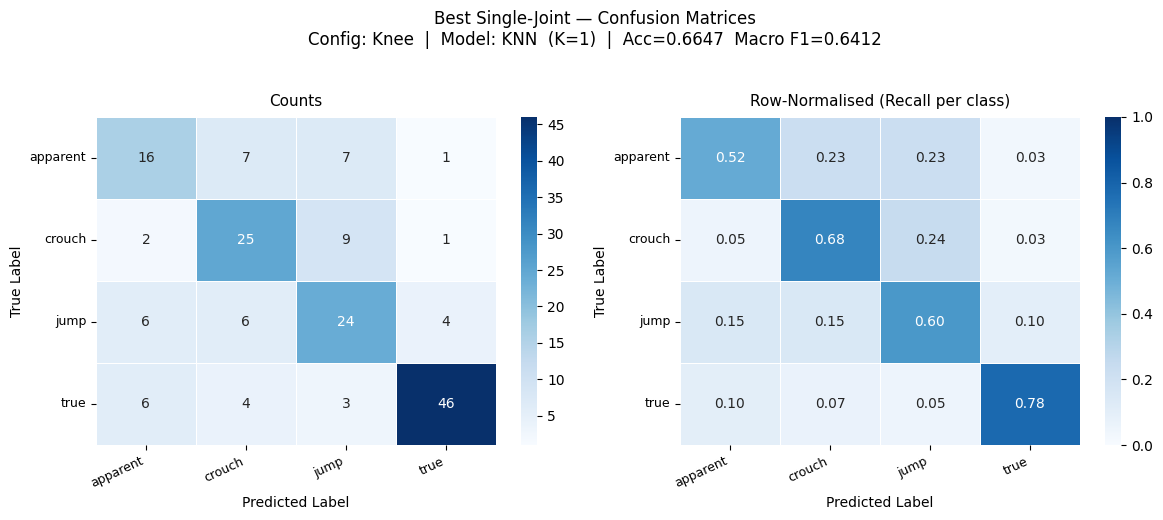

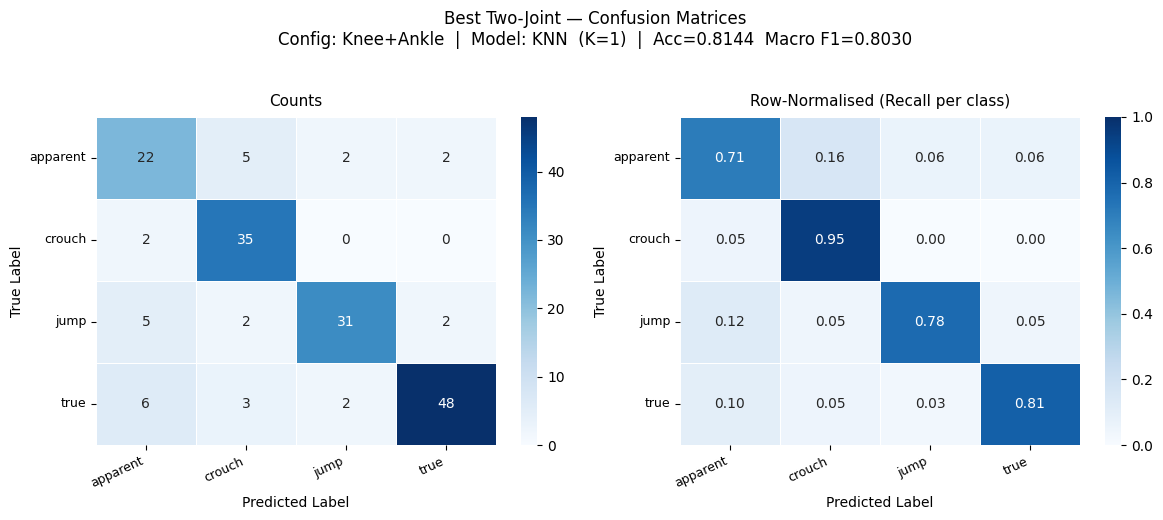

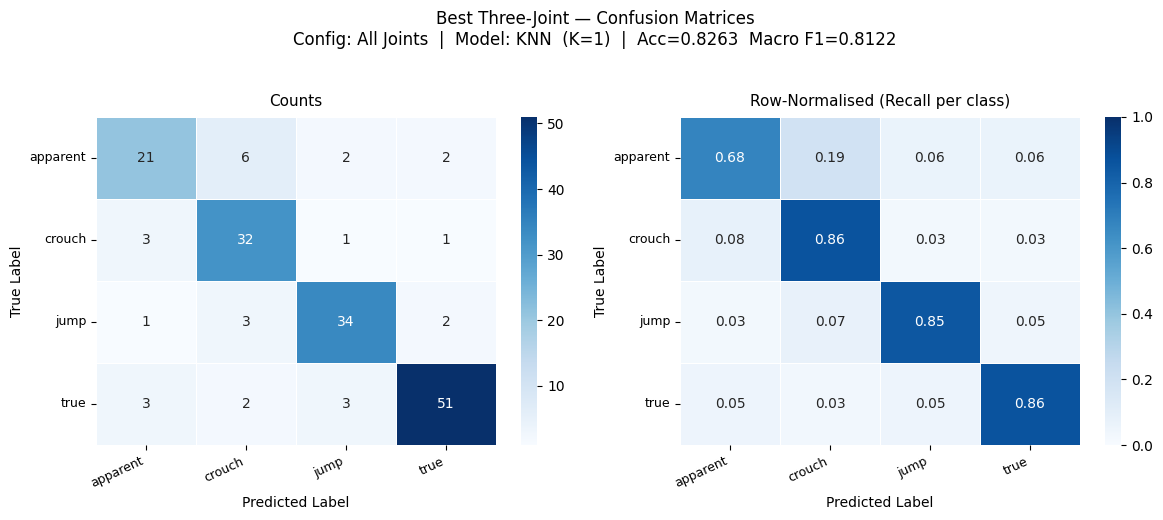

In [41]:
# Automatically select the three best cases 
METRIC = "F1"

single_joint_configs = ["Hip", "Knee", "Ankle"]
two_joint_configs    = ["Hip+Knee", "Hip+Ankle", "Knee+Ankle"]
three_joint_configs  = ["All Joints"]

def best_for_group(config_group, metric=METRIC):
    """Return (config_name, model_name, row) with highest metric in the group."""
    subset = results_df[results_df["Config"].isin(config_group)]
    best_row = subset.loc[subset[metric].idxmax()]
    return best_row["Config"], best_row["Model"], best_row

best_single_config, best_single_model, best_single_row = best_for_group(single_joint_configs)
best_two_config,    best_two_model,    best_two_row    = best_for_group(two_joint_configs)
best_three_config,  best_three_model,  best_three_row  = best_for_group(three_joint_configs)

selected_cases = [
    ("Best Single-Joint",   best_single_config, best_single_model, best_single_row),
    ("Best Two-Joint",      best_two_config,    best_two_model,    best_two_row),
    ("Best Three-Joint",    best_three_config,  best_three_model,  best_three_row),
]

print("Selected cases for confusion matrix visualisation:")
print(f"  {'Group':<20} {'Config':<15} {'Model':<22} {METRIC}")
print("  " + "-" * 68)
for group_label, cfg, mdl, row in selected_cases:
    print(f"  {group_label:<20} {cfg:<15} {mdl:<22} {row[METRIC]:.4f}")

# Plot: each selected case in its own figure
for group_label, cfg, mdl, res_row in selected_cases:
    y_pred_sel = all_y_pred[(cfg, mdl)]
    cm      = confusion_matrix(y_test, y_pred_sel)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    acc = res_row["Accuracy"]
    f1  = res_row["F1"]
    knn_suffix = f"  (K={knn_best_k[cfg]})" if mdl == "KNN" else ""

    main_title = (f"{group_label} — Confusion Matrices\n"
                  f"Config: {cfg}  |  Model: {mdl}{knn_suffix}  |  "
                  f"Acc={acc:.4f}  Macro F1={f1:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(main_title, fontsize=12, y=1.03)

    # Left — raw counts
    ax_left = axes[0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax_left, linewidths=0.5, annot_kws={"size": 10})
    ax_left.set_title("Counts", fontsize=11, pad=8)
    ax_left.set_xlabel("Predicted Label")
    ax_left.set_ylabel("True Label")
    ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=25, ha='right', fontsize=9)
    ax_left.set_yticklabels(ax_left.get_yticklabels(), rotation=0, fontsize=9)

    # Right — row-normalised
    ax_right = axes[1]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax_right, linewidths=0.5, annot_kws={"size": 10},
                vmin=0, vmax=1)
    ax_right.set_title("Row-Normalised (Recall per class)", fontsize=11, pad=8)
    ax_right.set_xlabel("Predicted Label")
    ax_right.set_ylabel("True Label")
    ax_right.set_xticklabels(ax_right.get_xticklabels(), rotation=25, ha='right', fontsize=9)
    ax_right.set_yticklabels(ax_right.get_yticklabels(), rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()
